In [1]:
# Cell 1 - install packages
!pip install ultralytics roboflow

# Cell 2 - download dataset
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="F7j5UIixt7fmJQVXbgaI")
project = rf.workspace("dendel-pino-27gsx").project("motorcycle-helmet-fhsbn")
version = project.version(1)
dataset = version.download("yolov8")


# Cell 3 - train
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(data=f"{dataset.location}/data.yaml", epochs=50, imgsz=640)

# Cell 4 - test it on an image
results = model("path/to/test_image.jpg")
results[0].show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Motorcycle-Helmet-1 in yolov8:: 100%|██████████| 1270/1270 [00:00<00:00, 8450.14it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Motorcycle-Helmet-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False

FileNotFoundError: path/to/test_image.jpg does not exist


image 1/1 /content/Motorcycle-Helmet-1/valid/images/BikesHelmets665_png.rf.f9160cd927bd7a6baec5faf5cd1d2d23.jpg: 640x640 1 With Helmet, 2 Without Helmets, 8.7ms
Speed: 2.9ms preprocess, 8.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


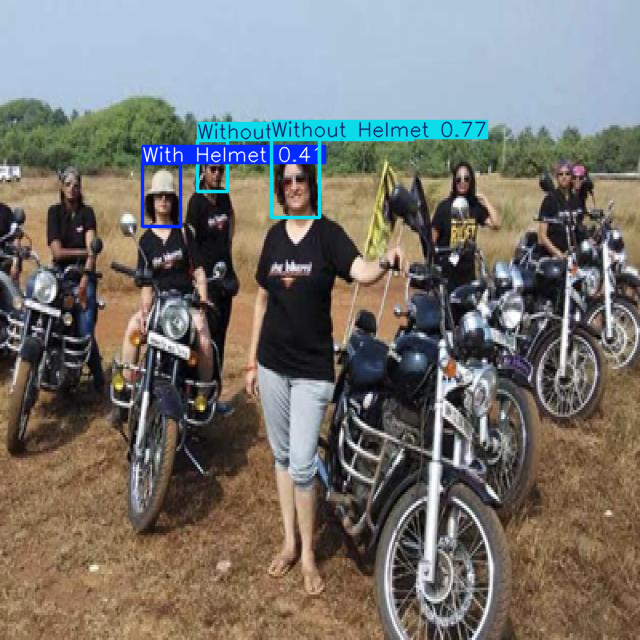

In [2]:
import os
val_folder = f"{dataset.location}/valid/images"
test_img = os.path.join(val_folder, os.listdir(val_folder)[0])  # picks the first image
results = model(test_img)
results[0].show()

In [4]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()  # click "Choose Files" and pick your image

image_name = list(uploaded.keys())[0]
img = Image.open(io.BytesIO(uploaded[image_name]))

Saving images.jpeg to images (1).jpeg



0: 480x640 2 With Helmets, 43.8ms
Speed: 3.3ms preprocess, 43.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


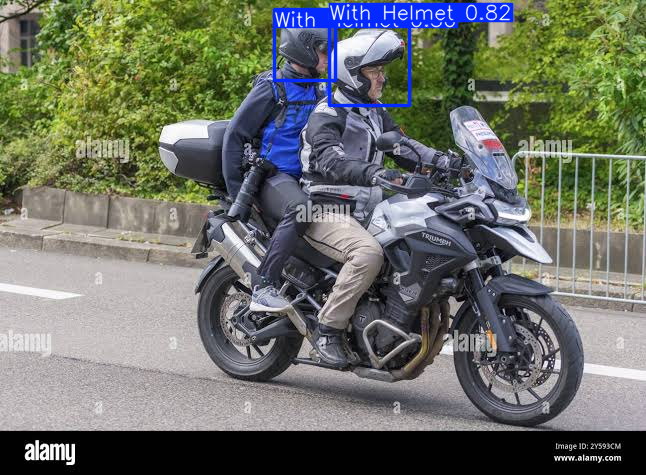

In [6]:
results = model.predict(img)
results[0].show()